--- Dataset Overview ---
Total Rows: 7787
Total Columns: 12

--- Missing Values Count ---
show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64


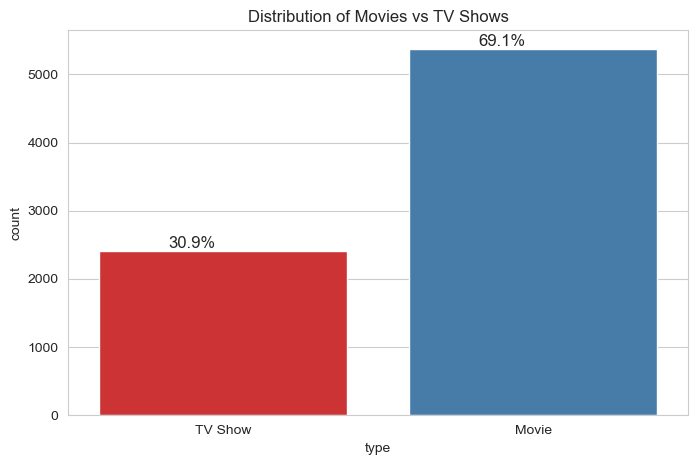

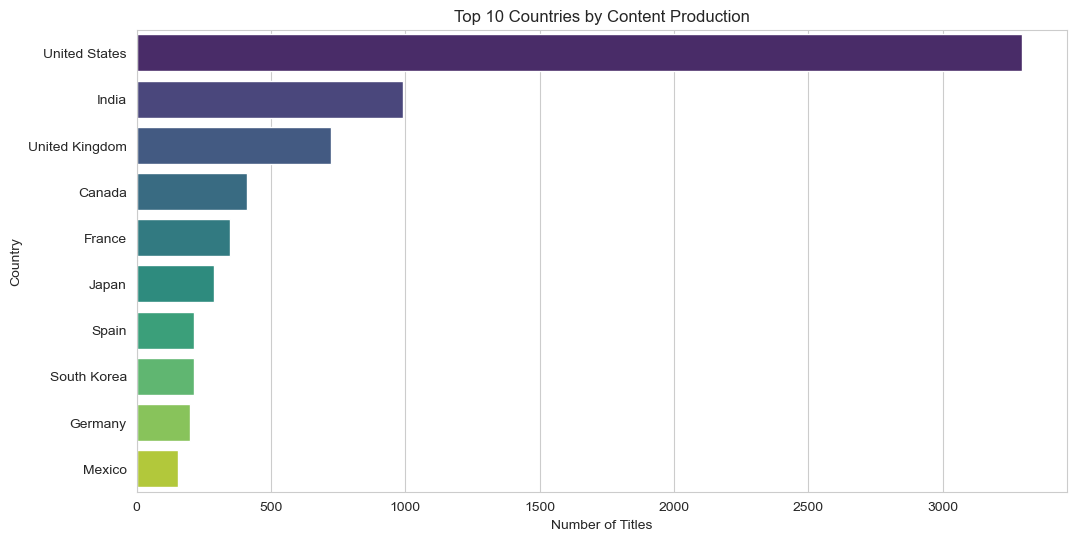

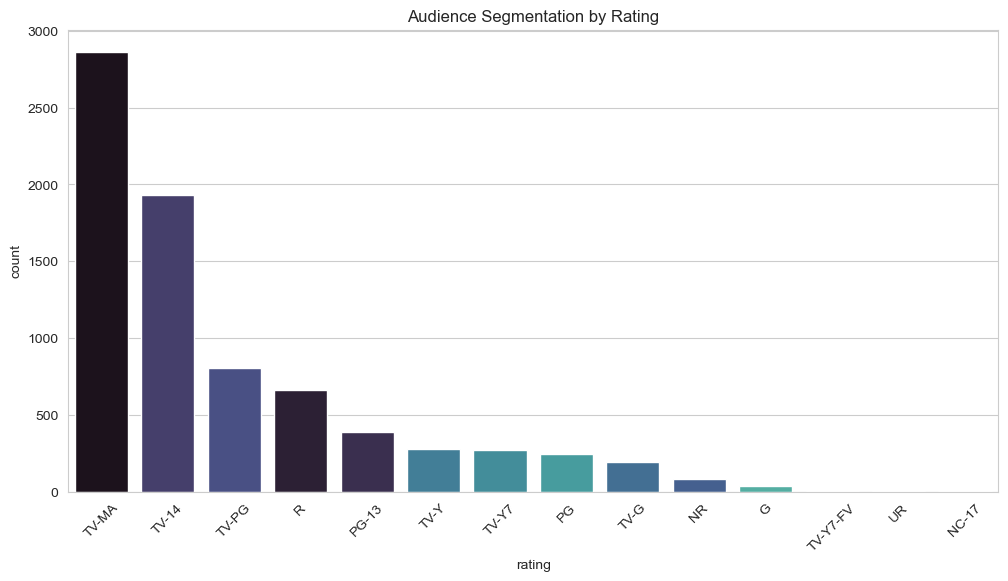

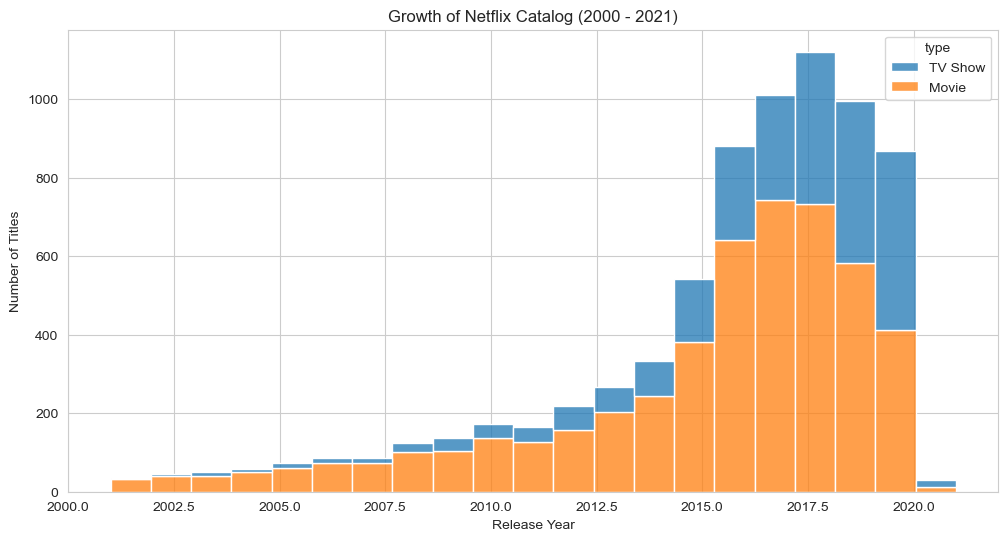


--- Summary for Project Report ---
The catalog is dominated by Movies.
Top Country: United States
Most frequent rating: TV-MA


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD AND INSPECT DATA
df = pd.read_csv(r'C:\Users\Soumya_SRB\Desktop\Netflix-Content-Clustering-Engine\NetflixSimple.csv')
print("--- Dataset Overview ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

# Check for missing values
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

 
# 2. CONTENT TYPE DISTRIBUTION 
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
ax = sns.countplot(x='type', data=df, hue='type', palette='Set1', legend=False)

# Add percentage labels on top of bars
total = len(df)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = '{:.1f}%'.format(100 * height/total)
        x = p.get_x() + p.get_width() / 2 - 0.1
        y = height
        ax.annotate(percentage, (x, y), size = 12, va='bottom', ha='center')
plt.title('Distribution of Movies vs TV Shows')
plt.show()



#TOP 10 PRODUCING COUNTRIES 
countries_data = df['country'].dropna().str.split(', ')
all_countries = [country for sublist in countries_data for country in sublist]
top_10_countries = pd.Series(all_countries).value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_countries.values, 
            y=top_10_countries.index, 
            hue=top_10_countries.index, 
            palette='viridis', 
            legend=False)
plt.title('Top 10 Countries by Content Production')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()



# RATING DISTRIBUTION 
plt.figure(figsize=(12, 6))
rating_order = df['rating'].value_counts().index
sns.countplot(x='rating', data=df, order=rating_order, hue='rating', palette='mako', legend=False)
plt.title('Audience Segmentation by Rating')
plt.xticks(rotation=45)
plt.show()



#  CONTENT GROWTH TRENDS
plt.figure(figsize=(12, 6))
# Filter to see the trend since 2000
recent_df = df[df['release_year'] > 2000]
# Note: histplot handles hue correctly without warnings
sns.histplot(data=recent_df, x='release_year', hue='type', multiple='stack', bins=21)
plt.title('Growth of Netflix Catalog (2000 - 2021)')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()



#  SUMMARY STATISTICS FOR REPORT
print("\n--- Summary for Project Report ---")
print(f"The catalog is dominated by {df['type'].value_counts().index[0]}s.")
print(f"Top Country: {top_10_countries.index[0]}")
print(f"Most frequent rating: {df['rating'].mode()[0]}")